In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  str    
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), str(1)
memory usage: 234.5 KB


In [4]:
df["Height"].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

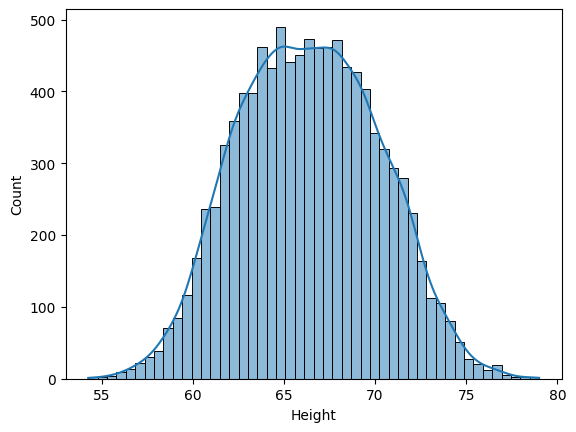

In [7]:
sns.histplot(df["Height"], kde=True)

<Axes: xlabel='Weight', ylabel='Count'>

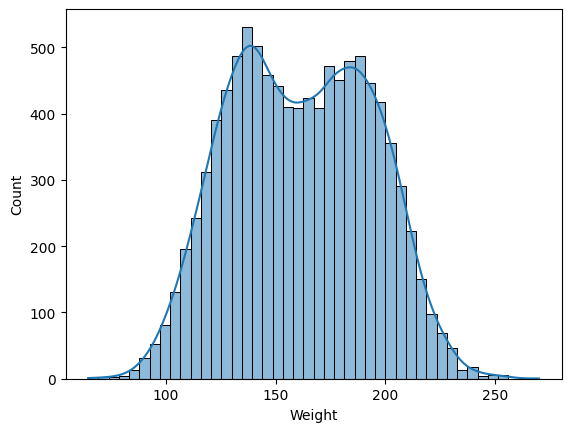

In [8]:
sns.histplot(df["Weight"], kde = True)

<Axes: xlabel='Height'>

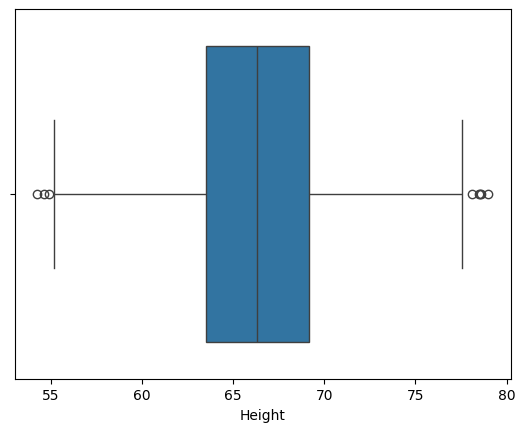

In [17]:
sns.boxplot(df["Height"], orient="h") # Here are visible outlier so we will trim them using percentile method

In [19]:
upper_limit = df["Height"].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [20]:
lower_limit = df["Height"].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [22]:
df[(df["Height"] >= upper_limit) | (df["Height"] <= lower_limit)] # These are the outlier's in our dataset

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [27]:
# Now lets create new dataset which doesn't contain any outlier
new_df = df[(df["Height"] < upper_limit) & (df["Height"] >lower_limit)]

In [28]:
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


<Axes: xlabel='Height'>

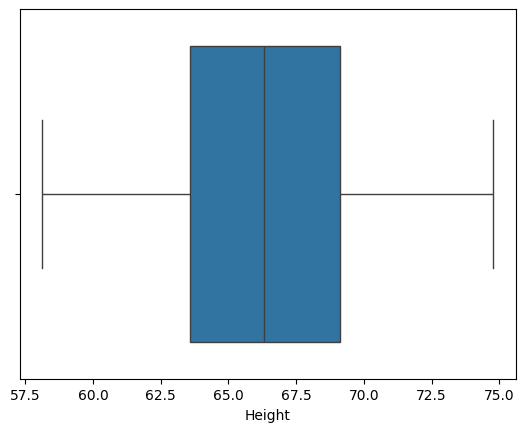

In [34]:
# Lets visualize the data distribution after trimming
sns.boxplot(new_df["Height"], orient="h")

<Axes: xlabel='Height', ylabel='Count'>

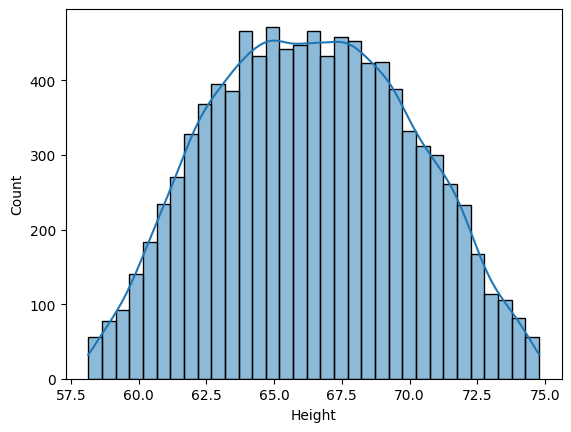

In [36]:
sns.histplot(new_df["Height"], kde=True)

In [37]:
# Capping ----> Winzorization
#Capping in percentile is known as Winzorization
df["Height"] = np.where(df["Height"]>=upper_limit, 
                        upper_limit,
                        np.where(
                            df["Height"] <= lower_limit,
                            lower_limit,
                            df["Height"]
                        ))

In [39]:
#Capping is done now let's check stats
df["Height"].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

<Axes: xlabel='Height'>

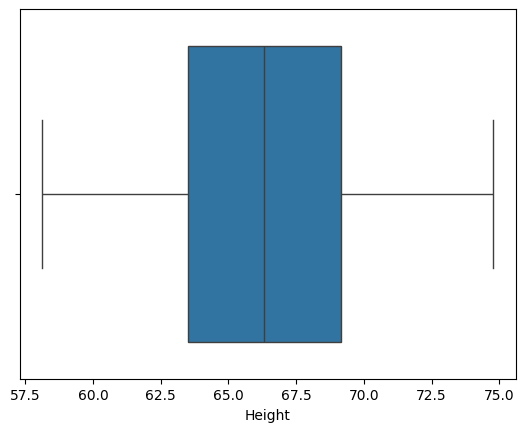

In [ ]:
sns.boxplot(df["Height"], orient="h") # Outlier is capped without trimming

<Axes: xlabel='Height', ylabel='Count'>

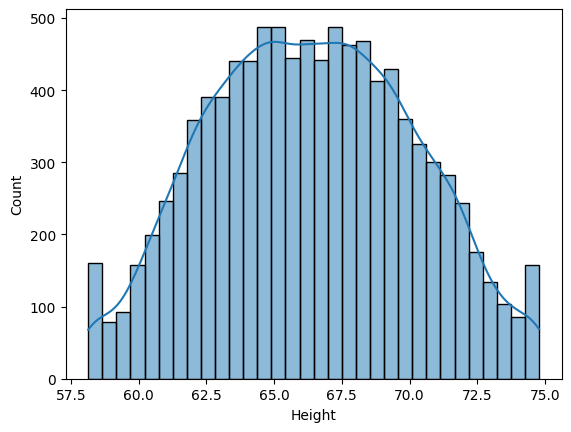

In [41]:
# And also lets see the distribution of Height column 
sns.histplot(df["Height"], kde=True)